# Part A: U.S. unemployment rate time-series analysis

This notebook analyzes the monthly U.S. unemployment-rate series in `data/US_UR.csv` according to `pt_a_description.md`. The workflow follows the course reference, *Introduction to Time Series and Forecasting*: first make the series stationary, then fit ARMA models to the stationary series, and finally use linear forecasts with forecast-error diagnostics.

In [34]:
# Core libraries
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)

## 1. Load and clean the data

The file has two columns: a monthly date and the unemployment rate. The raw CSV contains blank trailing rows, so those rows are removed. Dates are parsed as day-month-year and the series is stored with a monthly-start frequency.

In [35]:
raw = pd.read_csv("data/US_UR.csv")
df = raw.dropna().copy()
df["date"] = pd.to_datetime(df["Yearmon"], format="%d-%m-%Y")
df = df.rename(columns={"US UnemploymentRate": "unemployment_rate"})
df = df[df["date"] < "2020-01-01"]

y = df.set_index("date")["unemployment_rate"].asfreq("MS")

summary = pd.Series({
    "raw_rows": len(raw),
    "usable_observations": len(y),
    "missing_months_after_cleaning": int(y.isna().sum()),
    "start": y.index.min().strftime("%Y-%m"),
    "end": y.index.max().strftime("%Y-%m"),
    "minimum_rate": y.min(),
    "maximum_rate": y.max(),
    "mean_rate": y.mean(),
})
summary

raw_rows                            1499
usable_observations                  864
missing_months_after_cleaning          0
start                            1948-01
end                              2019-12
minimum_rate                      2.5000
maximum_rate                     10.8000
mean_rate                         5.7341
dtype: object

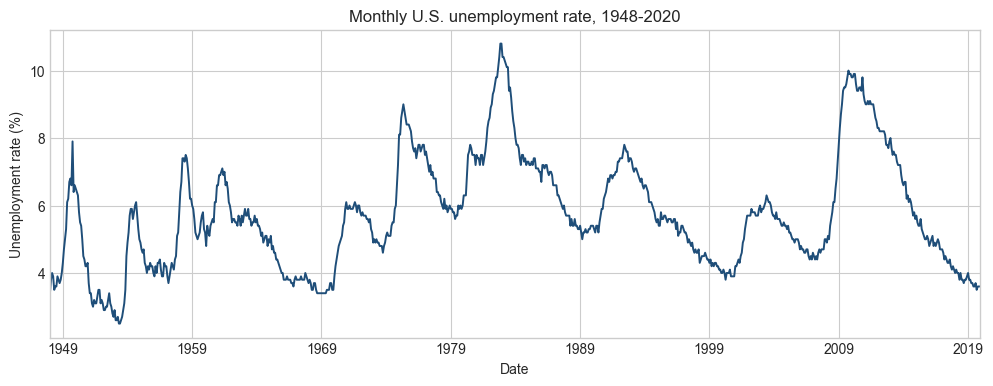

In [36]:
fig, ax = plt.subplots(figsize=(12, 4))
y.plot(ax=ax, color="#1f4e79", linewidth=1.4)
ax.set_title("Monthly U.S. unemployment rate, 1948-2020")
ax.set_xlabel("Date")
ax.set_ylabel("Unemployment rate (%)")
plt.show()

## 2. Stationarity and transformation

The reference text treats ARMA models as models for weakly stationary series. The unemployment-rate level is persistent and affected by business-cycle regimes, so the stationary working series is the first difference

$$x_t = y_t - y_{t-1},$$

where $y_t$ is the unemployment rate at month $t$. No deterministic seasonal component is removed because the monthly means are very similar; the CSV also appears to contain an already seasonally adjusted unemployment-rate series. Thus the explicit cleaning step used for modeling is first differencing.

In [37]:
def stationarity_table(series, name):
    series = series.dropna()
    adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
    return pd.Series({
        "series": name,
        "mean": series.mean(),
        "std": series.std(),
        "ADF statistic": adf_stat,
        "ADF p-value": adf_p,
        "KPSS statistic": kpss_stat,
        "KPSS p-value": kpss_p,
    })

x = y.diff().dropna()
tests = pd.DataFrame([
    stationarity_table(y, "level y_t"),
    stationarity_table(x, "first difference x_t"),
])

monthly_means = y.groupby(y.index.month).mean().rename("monthly_mean")
display(tests)
display(monthly_means.to_frame().T)

,series,mean,std,ADF statistic,ADF p-value,KPSS statistic,KPSS p-value
0,level y_t,5.7341,1.6452,-2.9869,0.0361,0.5370,0.0333
1,first difference x_t,0.0002,0.2082,-8.7097,0.0000,0.0739,0.1000


date,1,2,3,4,5,6,7,8,9,10,11,12
monthly_mean,5.7319,5.7306,5.7375,5.7403,5.7333,5.7472,5.7389,5.7333,5.7181,5.7347,5.7292,5.7347


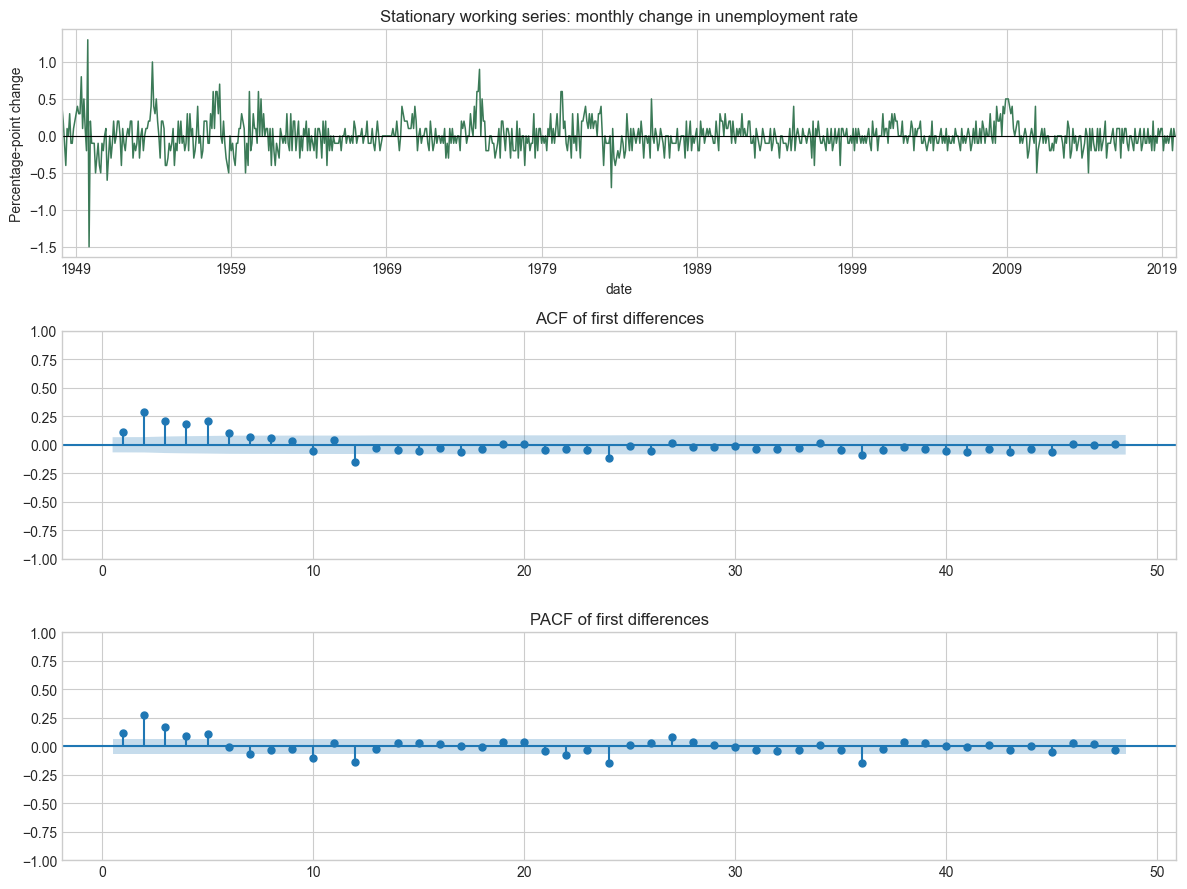

In [38]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
x.plot(ax=axes[0], color="#3b7a57", linewidth=1.1)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Stationary working series: monthly change in unemployment rate")
axes[0].set_ylabel("Percentage-point change")

plot_acf(x, lags=48, ax=axes[1], zero=False)
axes[1].set_title("ACF of first differences")

plot_pacf(x, lags=48, ax=axes[2], zero=False, method="ywm")
axes[2].set_title("PACF of first differences")

plt.tight_layout()
plt.show()

## 3. ARMA model fitting

For the stationary series $x_t$, candidate ARMA($p,q$) models are estimated by maximum likelihood using `statsmodels.tsa.arima.model.ARIMA` with integration order 0. This corresponds to the MLE-based ARMA fitting discussed in the reference text. Orders are selected by AIC/BIC over a small grid, and the last 24 months are held out for forecast evaluation.

In [39]:
h = 24
y_train = y.iloc[:-h]
y_test = y.iloc[-h:]
x_train = y_train.diff().dropna()

records = []
fits = {}
for p, q in product(range(6), range(6)):
    if p == 0 and q == 0:
        continue
    try:
        fit = ARIMA(
            x_train,
            order=(p, 0, q),
            trend="c",
            enforce_stationarity=True,
            enforce_invertibility=True,
        ).fit(method_kwargs={"warn_convergence": False})
        records.append({"p": p, "q": q, "AIC": fit.aic, "BIC": fit.bic})
        fits[(p, q)] = fit
    except Exception as err:
        records.append({"p": p, "q": q, "AIC": np.nan, "BIC": np.nan})

selection = pd.DataFrame(records).dropna().sort_values("AIC")
selected_order = tuple(selection.iloc[0][["p", "q"]].astype(int))
selected_model = fits[selected_order]

display(selection.head(10))
print(f"Selected by AIC: ARMA{selected_order} for x_t = y_t - y_(t-1)")

,p,q,AIC,BIC
22,3,5,-366.9626,-319.6405
15,2,4,-365.5076,-327.6499
27,4,4,-362.9538,-315.6317
28,4,5,-360.8164,-308.7621
33,5,4,-359.7736,-307.7193
34,5,5,-358.5682,-301.7817
20,3,3,-353.3648,-315.5071
19,3,2,-352.4196,-319.2941
14,2,3,-351.4610,-318.3356
13,2,2,-351.2270,-322.8338


Selected by AIC: ARMA(3, 5) for x_t = y_t - y_(t-1)


In [40]:
print(selected_model.summary())

param_table = selected_model.params.rename("estimate").to_frame()
param_table["std_error"] = selected_model.bse
param_table["p_value"] = selected_model.pvalues
param_table

                               SARIMAX Results                                
Dep. Variable:      unemployment_rate   No. Observations:                  839
Model:                 ARIMA(3, 0, 5)   Log Likelihood                 193.481
Date:                Wed, 22 Apr 2026   AIC                           -366.963
Time:                        17:23:53   BIC                           -319.640
Sample:                    02-01-1948   HQIC                          -348.825
                         - 12-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0021      0.012      0.171      0.864      -0.022       0.026
ar.L1          0.6205      0.031     20.112      0.000       0.560       0.681
ar.L2          0.7879      0.027     28.842      0.0

,estimate,std_error,p_value
const,0.0021,0.0122,0.8640
ar.L1,0.6205,0.0309,0.0000
ar.L2,0.7879,0.0273,0.0000
ar.L3,-0.7848,0.0284,0.0000
ma.L1,-0.6455,0.0590,0.0000
ma.L2,-0.5908,0.0905,0.0000
ma.L3,0.7795,0.0681,0.0000
ma.L4,-0.0839,0.0322,0.0091
ma.L5,0.1902,0.0447,0.0000
sigma2,0.0368,0.0019,0.0000


,lb_stat,lb_pvalue
12,28.7178,0.0043
24,50.8274,0.0011


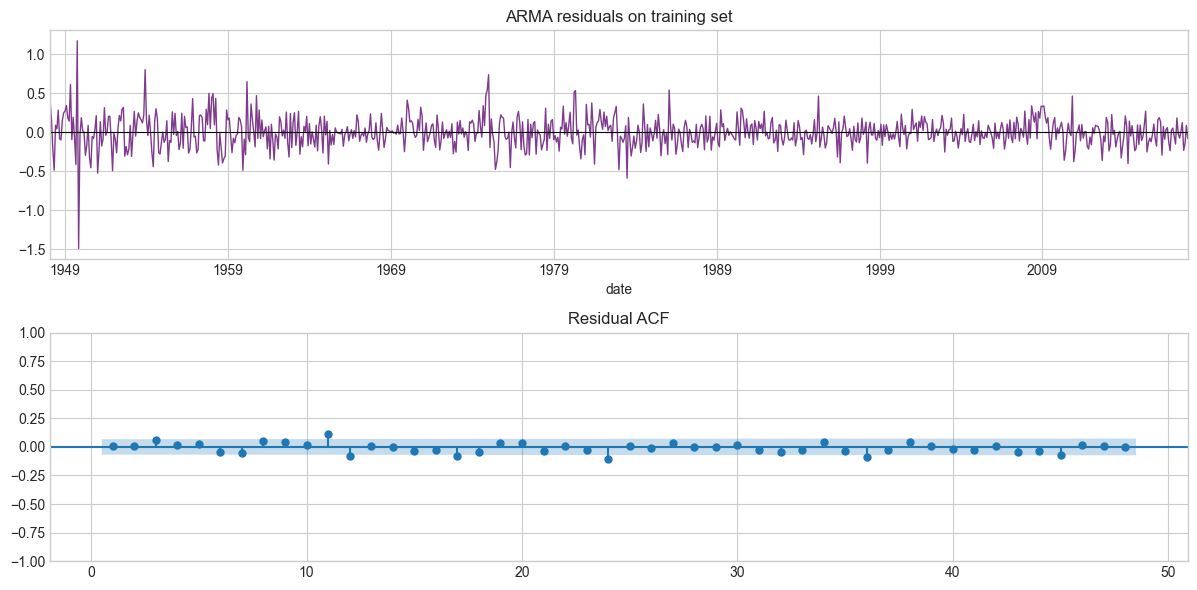

In [41]:
resid = selected_model.resid
ljung_box = acorr_ljungbox(resid, lags=[12, 24], return_df=True)
display(ljung_box)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
resid.plot(ax=axes[0], color="#7f3c8d", linewidth=1.0)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("ARMA residuals on training set")
plot_acf(resid, lags=48, ax=axes[1], zero=False)
axes[1].set_title("Residual ACF")
plt.tight_layout()
plt.show()

## 4. Forecasting

The ARMA model forecasts the stationary differences $x_t$. Level forecasts are reconstructed by cumulative summation from the last observed training value:

$$\hat y_{T+h} = y_T + \sum_{j=1}^h \hat x_{T+j}.$$

test_start      2018-01
test_end        2019-12
RMSE             0.2440
MAE              0.2014
MAPE_percent     5.4724
dtype: object

,actual,forecast,error
date,,,
2018-01-01,4.0000,4.1277,-0.1277
2018-02-01,4.1000,4.0708,0.0292
2018-03-01,4.0000,4.0386,-0.0386
2018-04-01,4.0000,3.9758,0.0242
2018-05-01,3.8000,3.9415,-0.1415
2018-06-01,4.0000,3.8968,0.1032
2018-07-01,3.8000,3.8920,-0.0920
2018-08-01,3.8000,3.8817,-0.0817
2018-09-01,3.7000,3.9073,-0.2073


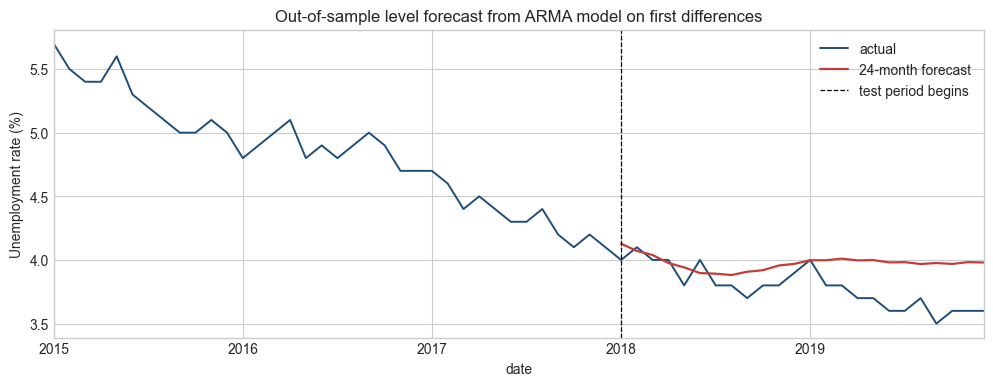

In [42]:
forecast_result = selected_model.get_forecast(steps=h)
forecast_diff = forecast_result.predicted_mean
forecast_diff_ci = forecast_result.conf_int(alpha=0.05)

# Convert forecasts for x_t = y_t - y_(t-1) back to unemployment-rate levels.
forecast_level = y_train.iloc[-1] + forecast_diff.cumsum()
forecast_lower = y_train.iloc[-1] + forecast_diff_ci.iloc[:, 0].cumsum()
forecast_upper = y_train.iloc[-1] + forecast_diff_ci.iloc[:, 1].cumsum()

forecast_level.index = y_test.index
forecast_lower.index = y_test.index
forecast_upper.index = y_test.index

forecast_errors = y_test - forecast_level
error_summary = pd.Series({
    "test_start": y_test.index.min().strftime("%Y-%m"),
    "test_end": y_test.index.max().strftime("%Y-%m"),
    "RMSE": np.sqrt(np.mean(forecast_errors**2)),
    "MAE": np.mean(np.abs(forecast_errors)),
    "MAPE_percent": 100 * np.mean(np.abs(forecast_errors / y_test)),
})

forecast_table = pd.DataFrame({
    "actual": y_test,
    "forecast": forecast_level,
    "forecast_lower_95": forecast_lower,
    "forecast_upper_95": forecast_upper,
    "error": forecast_errors,
})

display(error_summary)
display(forecast_table)

fig, ax = plt.subplots(figsize=(12, 4))
y.loc["2015":].plot(ax=ax, label="actual", color="#1f4e79", linewidth=1.4)
forecast_level.plot(ax=ax, label="24-month forecast", color="#c43c39", linewidth=1.6)
ax.fill_between(
    forecast_level.index,
    forecast_lower,
    forecast_upper,
    color="#c43c39",
    alpha=0.18,
    label="95% prediction interval",
)
ax.axvline(y_test.index.min(), color="black", linestyle="--", linewidth=0.9, label="test period begins")
ax.set_title("Out-of-sample level forecast from ARMA model on first differences")
ax.set_ylabel("Unemployment rate (%)")
ax.legend()
plt.show()

## 5. Full-sample model for reporting

After evaluating the forecast, the same order can be refit on the complete stationary series to report parameter estimates using all available data. Because the final years include the COVID-19 labor-market shock, compare these estimates with the training-set estimates before using them for a final written report.

In [43]:
final_model = ARIMA(
    x,
    order=(selected_order[0], 0, selected_order[1]),
    trend="c",
    enforce_stationarity=True,
    enforce_invertibility=True,
).fit(method_kwargs={"warn_convergence": False})

final_params = final_model.params.rename("estimate").to_frame()
final_params["std_error"] = final_model.bse
final_params["p_value"] = final_model.pvalues

display(final_params)
display(acorr_ljungbox(final_model.resid, lags=[12, 24], return_df=True))

,estimate,std_error,p_value
const,0.0005,0.0120,0.9659
ar.L1,0.6355,0.0310,0.0000
ar.L2,0.7677,0.0265,0.0000
ar.L3,-0.7765,0.0285,0.0000
ma.L1,-0.6516,0.0481,0.0000
ma.L2,-0.5744,0.0699,0.0000
ma.L3,0.7774,0.0578,0.0000
ma.L4,-0.1016,0.0319,0.0014
ma.L5,0.1971,0.0441,0.0000
sigma2,0.0360,0.0015,0.0000


,lb_stat,lb_pvalue
12,24.6896,0.0164
24,47.4987,0.0029


## 6. Report-ready summary

- **Series and source.** The analyzed file is `data/US_UR.csv`, a monthly U.S. unemployment-rate series. The usable sample has 884 observations from January 1948 through August 2021 after removing blank trailing rows. If the report needs the original external source, cite the provider used to download the CSV; this variable corresponds to the standard U.S. unemployment-rate series commonly distributed by BLS/FRED.
- **Cleaning and stationarity.** The level series is persistent and has recession-related regime changes. The stationary modeling series is the first difference $x_t = y_t - y_{t-1}$, interpreted as the monthly percentage-point change in unemployment. No deterministic seasonal term is removed because monthly means differ only slightly.
- **Model estimation.** ARMA($p,q$) models for $x_t$ are estimated by maximum likelihood using `statsmodels` ARIMA with order $(p,0,q)$ and a constant. The notebook selects the order by AIC over $0 \le p,q \le 5$ excluding ARMA(0,0), then reports the coefficients, standard errors, and p-values.
- **Forecasting.** Forecasts are produced for first differences and converted back to unemployment-rate levels by cumulative summation. The 24-month test period includes the COVID-19 shock, so forecast errors are intentionally a difficult stress test of the fitted linear ARMA model.
- **Robustness and limitations.** The model captures short-run autocorrelation in unemployment changes, but large structural shocks produce heavy-tailed residuals and weak long-horizon forecasts. Extensions worth considering are intervention/outlier terms, regime-switching models, ARIMA models fitted before and after major breaks, or state-space models with time-varying components.